In [1]:
import cv2
import random
import insightface
import numpy as np
import pandas as pd
from tqdm import tqdm
from datetime import datetime
import matplotlib.pyplot as plt
from insightface.app import FaceAnalysis

In [16]:
"""df = pd.read_pickle("./embeddings-0312.pkl")

is_array_col = df['embedding'].apply(lambda x: isinstance(x, np.ndarray))

# convert back to float32
df['embedding'] = df['embedding'].apply(lambda x: x.astype(np.float32))"""

'df = pd.read_pickle("./embeddings-0312.pkl")\n\nis_array_col = df[\'embedding\'].apply(lambda x: isinstance(x, np.ndarray))\n\n# convert back to float32\ndf[\'embedding\'] = df[\'embedding\'].apply(lambda x: x.astype(np.float32))'

# run

In [2]:
# img to embedding function

def img_to_embedding(img_path):

    # read img
    read_img = cv2.imread(img_path)

    # init face analysis app
    app = FaceAnalysis()

    # to prepare images 
    app.prepare(ctx_id=0)
    try:
        faces = app.get(read_img)[0]['embedding']
        return faces
    
    except Exception as e:
        print(f"Error in embedding function for {img_path}: {e}")
        return None

In [17]:
"""import glob
import os

root_folder = "/home/sho/insightface/gsi/img/sabrina"
image_paths = glob.glob(os.path.join(root_folder, "**", "*.JPG"), recursive=True)

# convert sabrina to emebddings
embeddings_data = []

for img_path in image_paths:
    try:
        embedding = img_to_embedding(img_path)
        if embedding is None:
            continue
        
        embeddings_data.append({
            "name":"Sabrina Ho",
            "ID":5749,
            "embedding": embedding,
            "embedding_type": type(embedding),
            "embedding_dtype": embedding.dtype,
            "embedding_size": embedding.size,
            "image_name": os.path.basename(img_path),
            "filepath": img_path
        })
    
    except Exception as e:
        print(f"Failed to process {img_path}: {e}")
"""

'import glob\nimport os\n\nroot_folder = "/home/sho/insightface/gsi/img/sabrina"\nimage_paths = glob.glob(os.path.join(root_folder, "**", "*.JPG"), recursive=True)\n\n# convert sabrina to emebddings\nembeddings_data = []\n\nfor img_path in image_paths:\n    try:\n        embedding = img_to_embedding(img_path)\n        if embedding is None:\n            continue\n\n        embeddings_data.append({\n            "name":"Sabrina Ho",\n            "ID":5749,\n            "embedding": embedding,\n            "embedding_type": type(embedding),\n            "embedding_dtype": embedding.dtype,\n            "embedding_size": embedding.size,\n            "image_name": os.path.basename(img_path),\n            "filepath": img_path\n        })\n\n    except Exception as e:\n        print(f"Failed to process {img_path}: {e}")\n'

In [ ]:
"""df_sab = pd.DataFrame(embeddings_data)
df_sabrina = pd.concat([df, df_sab], ignore_index=True)
print(f"original df shape:{df.shape}")
print(f"df with sabrina shape:{df_sabrina.shape}")

df_sabrina.to_pickle("embeddings_sabrina.pkl")"""

original df shape:(13195, 8)
df with sabrina shape:(13199, 10)


# start live demo

In [3]:
# load sabrina embedding pickle 
path = "/mnt/nas2/sabrina/face-gen/embeddings_sabrina.pkl"

df_sabrina = pd.read_pickle(path)

is_array_col = df_sabrina['embedding'].apply(lambda x: isinstance(x, np.ndarray))

# convert back to float32
df_sabrina['embedding'] = df_sabrina['embedding'].apply(lambda x: x.astype(np.float32))
print(df_sabrina.shape)


(13199, 10)


In [4]:
# query on live sabrina
query_path =  '/home/sho/insightface/gsi/img/demo.png'
query_sabrina = img_to_embedding(query_path)

/home/sho/anaconda3/envs/face-gen-notebook/lib/python3.13/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:118: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/sho/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/sho/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/sho/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/sho/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/sho/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (64

In [33]:
# brute force search
detector = insightface.model_zoo.get_model('/home/sho/.insightface/models/buffalo_l/w600k_r50.onnx')

def brute_force(df, query):
    # sim scores
    similarities = []

    start_time = datetime.now()
    
    for i in range(len(df)):
        emb = df['embedding'].iloc[i]
        sim = detector.compute_sim(query, emb)
        similarities.append(sim)

    # top 10
    top_k_indices = np.argsort(similarities)[::-1][:10]
    top_k_scores = [similarities[i] for i in top_k_indices]
    top_k_ids = [int(df.iloc[i]['ID']) for i in top_k_indices]

    end_time = datetime.now()
    duration = (end_time - start_time).total_seconds()
    print("search time: ", duration)

    print(f"top k person ID:{top_k_ids}")

    return top_k_indices, top_k_scores

/home/sho/anaconda3/envs/face-gen-notebook/lib/python3.13/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:118: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}


In [32]:
# hnsw search
import hnswlib

def hnsw_search(df, query):

    embedding_matrix = np.stack(df['embedding'].values)
    dim = embedding_matrix.shape[1]

    query_embedding = query.reshape(1, -1)

    start_time = datetime.now()
    # Build the index
    index_drop = hnswlib.Index(space='cosine', dim=dim)
    index_drop.init_index(max_elements=len(embedding_matrix), ef_construction=200, M=16)

    # Add embeddings to the index
    index_drop.add_items(embedding_matrix, np.arange(len(embedding_matrix)))
    
    top_k = 10
    labels, distances = index_drop.knn_query(query_embedding, k=top_k)

    top_k_indices = labels[0]
    top_k_scores = distances[0]
    top_k_ids = [df.iloc[idx]['ID'] for idx in top_k_indices]

    end_time = datetime.now()
    duration = (end_time - start_time).total_seconds()
    print("search time: ", duration)

    return top_k_indices, top_k_scores


In [30]:
# fvs search
import fvs_face_helper as fvs

def fvs_search(df, query):

    query = query.reshape((1, 512))

    start_time = datetime.now()
    response = fvs.face_search("56d7e7b2-4c17-47a9-b247-3710120b5466", query, 10, True )
    #print("response=", response)

    top_k_indices = response.indices[0]
    top_k_scores = response.distance[0]
    top_k_scores = [float(x) for x in top_k_scores]
    top_k_ids = [int(df.iloc[i]['ID']) for i in top_k_indices]

    end_time = datetime.now()
    duration = (end_time - start_time).total_seconds()
    print("search time: ", duration)

    print(f"top k person ID:{top_k_ids}")

    # 768

    return top_k_indices, top_k_scores


# show results

In [26]:
# plot
def plot_results(query_path, top_k_indices, top_k_scores, method):
    rows = 2
    cols = 5
    fig = plt.figure(figsize=(16, 10))

    # plot query
    query_img = cv2.imread(query_path)
    query_img_rgb = query_img[:, :, ::-1]

    ax = fig.add_subplot(rows + 1, cols, 1)
    ax.imshow(query_img_rgb)
    ax.set_title("query image")
    ax.axis("off")

    for i in range(1, cols):
        ax = fig.add_subplot(rows + 1, cols, i + 1)
        ax.axis("off")

    for idx, i in enumerate(top_k_indices):
        fp = df_sabrina.iloc[i]['filepath']
        read_img = cv2.imread(fp)
        read_img_rgb = read_img[:, :, ::-1]

        sim_score = top_k_scores[idx]

        ax = fig.add_subplot(rows + 1, cols, cols + idx + 1)  # start from row 2
        ax.imshow(read_img_rgb)
        if method == 'brute_force':
            title = f"ID: {df_sabrina.iloc[i]['ID']} | Sim (cosine sim): {sim_score:.4f}"
        elif method == 'hnsw':
            title = f"ID: {df_sabrina.iloc[i]['ID']} | Sim (cosine dist): {sim_score:.4f}"
        elif method == 'fvs':
            title = f"ID: {df_sabrina.iloc[i]['ID']} | Sim (hamming): {sim_score:.4f}"
        else:
            title = "method does not exist"
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

search time:  0.236057
top k person ID:[5749, 5749, 5749, 5749, 5708, 2340, 2612, 4684, 487, 380]


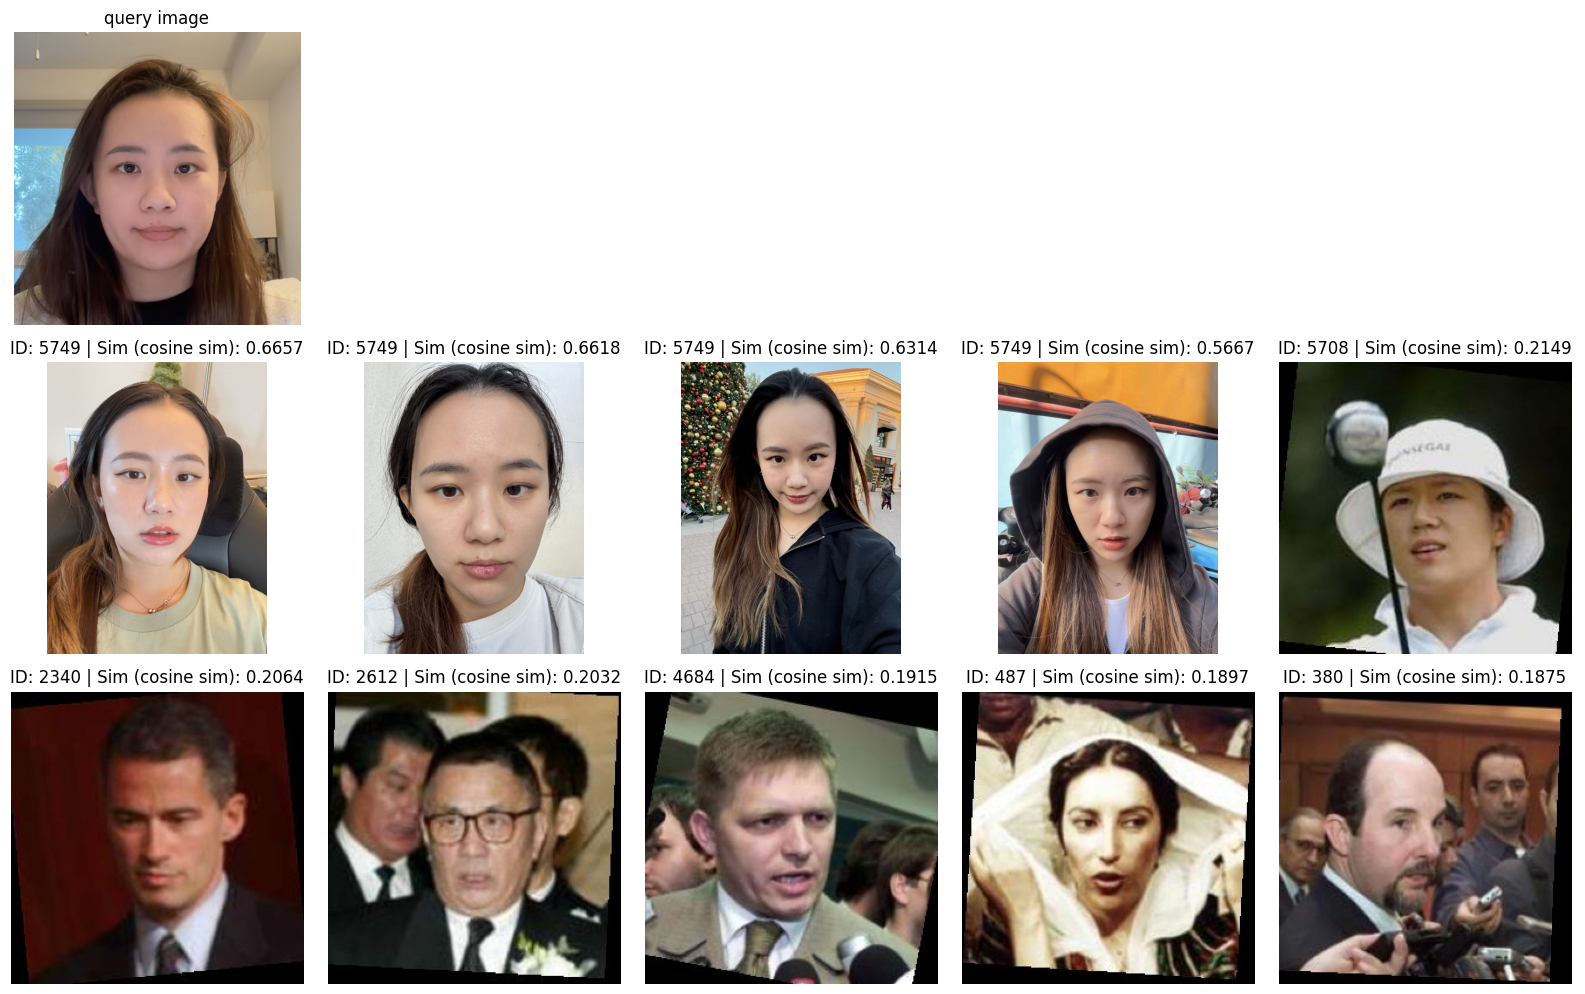

In [34]:
# brute force results
bf_ind, bf_scores = brute_force(df_sabrina, query_sabrina)
plot_results(query_path, bf_ind, bf_scores, 'brute_force')

search time:  0.224741


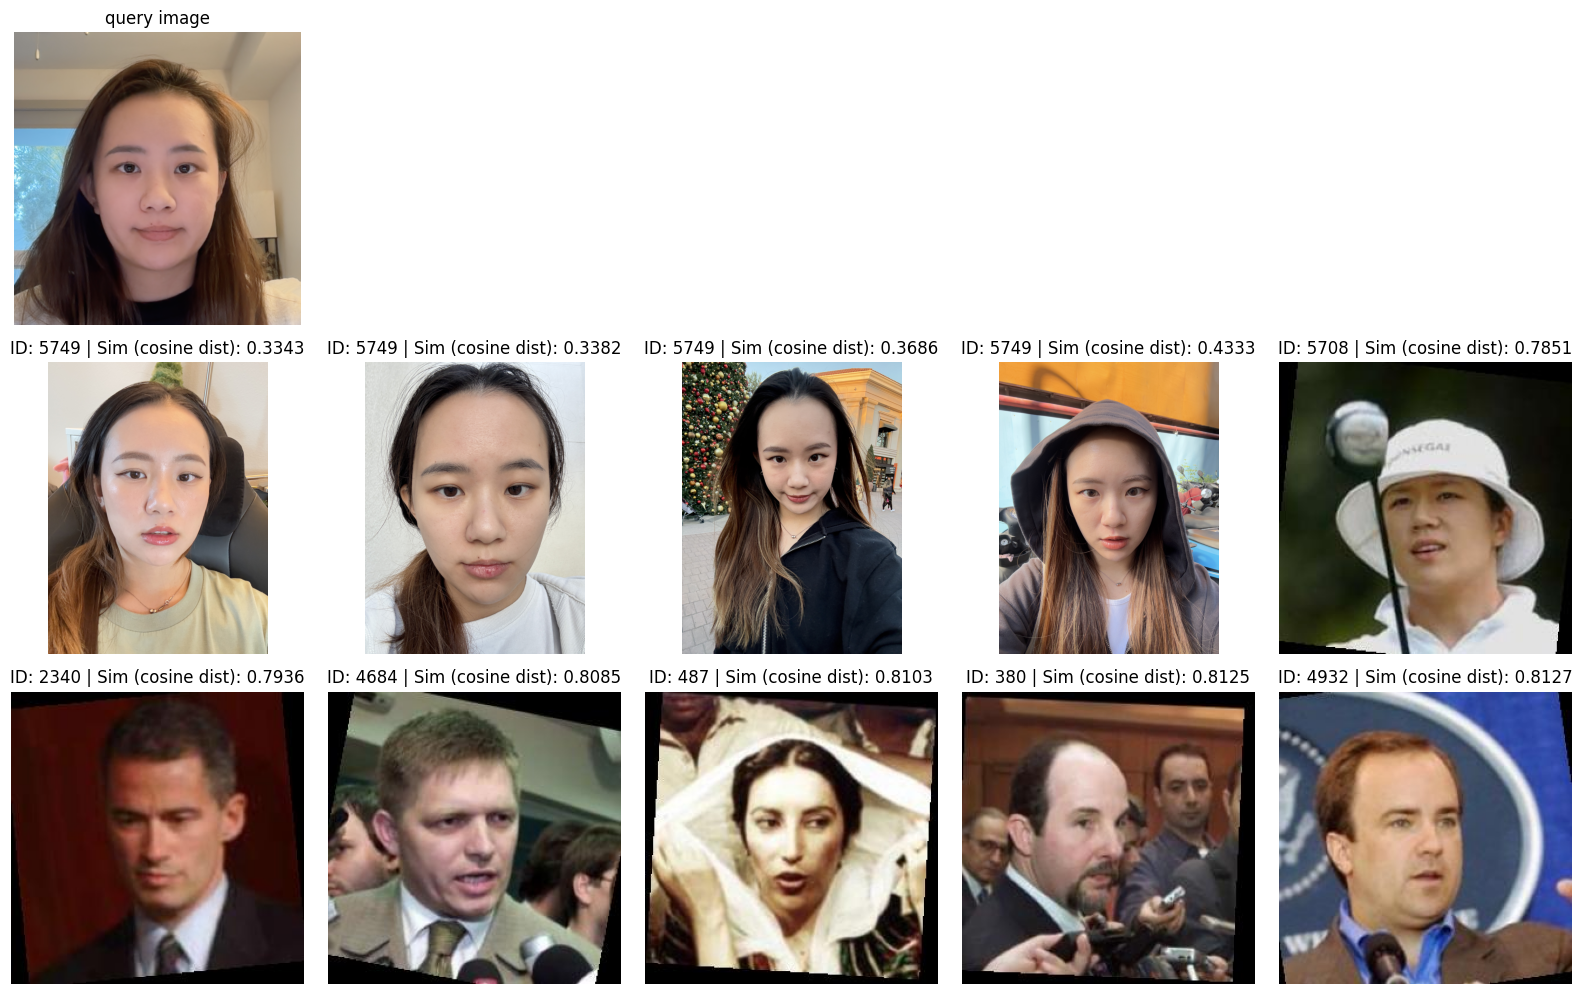

In [35]:
# hnsw results
hnsw_ind, hnsw_scores = hnsw_search(df_sabrina, query_sabrina)
plot_results(query_path, hnsw_ind, hnsw_scores, 'hnsw')


/home/sho/anaconda3/envs/face-gen-notebook/lib/python3.13/site-packages/ipykernel_launcher.py: starting search
/home/sho/anaconda3/envs/face-gen-notebook/lib/python3.13/site-packages/ipykernel_launcher.py: done searching
search time:  0.051979
top k person ID:[5749, 5749, 5749, 5749, 2340, 487, 5708, 380, 3631, 4684]


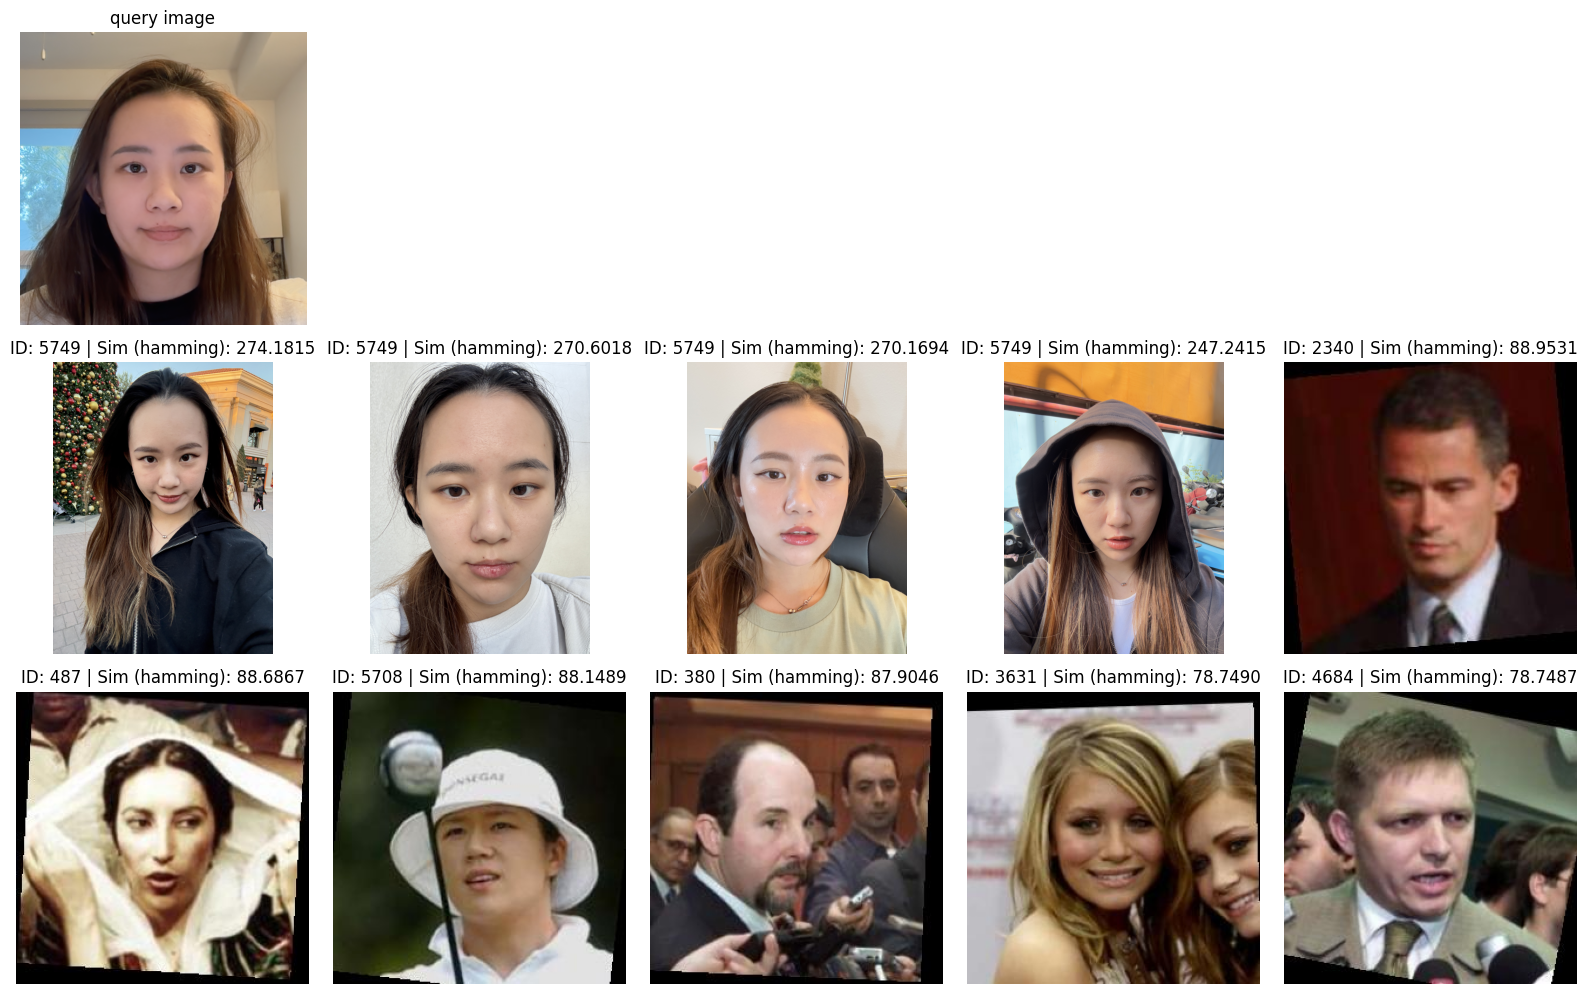

In [31]:
# fvs results
fvs_ind, fvs_scores = fvs_search(df_sabrina, query_sabrina)
plot_results(query_path, fvs_ind, fvs_scores, 'fvs')
